# SQL Business Analysis: Olist Brazilian E-Commerce Dataset

**Business question:** Which product categories and regions drive revenue, where does
delivery performance break down, and which customers/sellers matter most?

This notebook demonstrates core SQL techniques: filtering, aggregation, multi-table
joins, subqueries/CTEs, `HAVING`, `CASE WHEN`, and window functions against a real,
relational e-commerce dataset (~100k orders, 2016–2018), run locally with SQLite.

## Dataset Setup

1. Download the dataset from Kaggle: **Brazilian E-Commerce Public Dataset by Olist**
   (`olistbr/brazilian-ecommerce`) — free Kaggle account required.
   - Fastest path: there's already a ready-made SQLite version on Kaggle —
     **"E-commerce dataset by Olist (SQLite)"** by `terencicp` — download that
     and skip straight to Query 1 below (just point `sqlite3.connect()` at the file).
   - Otherwise, download the raw CSVs and run the loading cell below to build the
     database yourself (good practice — this is the same load step in a real pipeline).
2. Place the files in a `data/` folder next to this notebook.
3. Run all cells top to bottom.


In [12]:
import pandas as pd
import sqlite3

# --- OPTION A: you downloaded the ready-made SQLite file ---
# conn = sqlite3.connect("../data/olist.sqlite")

# --- OPTION B: you downloaded the raw CSVs and are building the DB yourself ---
conn = sqlite3.connect("../data/olist.db")

csv_to_table = {
    "customers":            "olist_customers_dataset.csv",
    "orders":                "olist_orders_dataset.csv",
    "order_items":           "olist_order_items_dataset.csv",
    "products":              "olist_products_dataset.csv",
    "sellers":               "olist_sellers_dataset.csv",
    "payments":              "olist_order_payments_dataset.csv",
    "reviews":               "olist_order_reviews_dataset.csv",
    "category_translation":  "product_category_name_translation.csv",
}

for table_name, filename in csv_to_table.items():
    df = pd.read_csv(f"../data/{filename}")
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    print(f"Loaded {table_name}: {len(df):,} rows")


Loaded customers: 99,441 rows
Loaded orders: 99,441 rows
Loaded order_items: 112,650 rows
Loaded products: 32,951 rows
Loaded sellers: 3,095 rows
Loaded payments: 103,886 rows
Loaded reviews: 99,224 rows
Loaded category_translation: 71 rows


## Step 1 — Confirm the schema loaded correctly
Always start by checking table names and row counts before writing business queries —
this is the same sanity-check habit used in the clustering and decision-tree projects.


In [13]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

for t in tables["name"]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn).iloc[0, 0]
    print(f"{t}: {n:,} rows")


                   name
0             customers
1                orders
2           order_items
3              products
4               sellers
5              payments
6               reviews
7  category_translation
customers: 99,441 rows
orders: 99,441 rows
order_items: 112,650 rows
products: 32,951 rows
sellers: 3,095 rows
payments: 103,886 rows
reviews: 99,224 rows
category_translation: 71 rows


## Query 1 — Order status breakdown
*Technique: `GROUP BY`, `COUNT`, `ORDER BY`*

Before analyzing revenue, confirm what share of orders actually completed —
cancelled/unavailable orders should usually be excluded from revenue analysis.


In [14]:
q1 = """
SELECT order_status, COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
"""
pd.read_sql(q1, conn)


,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


**Business insight:** 96,478 of 99,441 orders (**97.0%**) reached `delivered` status.
Cancelled and unavailable orders together account for only **1.24%** (1,234 orders), so
excluding them would not materially change the revenue rankings below. Revenue queries in
this notebook therefore include all order statuses; a stricter production analysis would
filter to `delivered` only.

## Query 2 — Revenue by product category
*Technique: 3-table `JOIN`, aggregation, `ROUND`, `LIMIT`*


In [15]:
q2 = """
SELECT
    ct.product_category_name_english AS category,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT oi.order_id) AS order_count
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql(q2, conn)


,category,total_revenue,order_count
0,health_beauty,1258681.34,8836
1,watches_gifts,1205005.68,5624
2,bed_bath_table,1036988.68,9417
3,sports_leisure,988048.97,7720
4,computers_accessories,911954.32,6689
5,furniture_decor,729762.49,6449
6,cool_stuff,635290.85,3632
7,housewares,632248.66,5884
8,auto,592720.11,3897
9,garden_tools,485256.46,3518


**Business insight:** `health_beauty` leads on total revenue (**R$1.26M** across 8,836
orders), but `watches_gifts` earns nearly as much (**R$1.21M**) from 36% fewer orders —
**R$214 per order versus R$142**. `bed_bath_table` has the highest order count of the top
three (9,417) but the lowest value per order (**R$110**).

Volume-driven and value-driven categories need different strategies: the first competes on
logistics efficiency and thin margins, the second on margin protection and customer
experience. A single "biggest push" recommendation would obscure that split.

## Query 3 — Revenue by customer state
*Technique: 3-table `JOIN` across orders → customers → order_items*


In [16]:
q3 = """
SELECT
    c.customer_state,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS order_count
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10;
"""
pd.read_sql(q3, conn)


,customer_state,total_revenue,order_count
0,SP,5202955.05,41375
1,RJ,1824092.67,12762
2,MG,1585308.03,11544
3,RS,750304.02,5432
4,PR,683083.76,4998
5,SC,520553.34,3612
6,BA,511349.99,3358
7,DF,302603.94,2125
8,GO,294591.95,2007
9,ES,275037.31,2025


**Business insight:** São Paulo generates **R$5.20M across 41,375 orders — 38% of all
platform revenue**. The top three states (SP R$5.20M, RJ R$1.82M, MG R$1.59M) together
account for **63%**.

That concentration is the platform's commercial strength and its clearest single point of
exposure: a logistics, regulatory, or competitive shock in one state would affect well over
a third of revenue.

## Query 4 — Average delivery time by state
*Technique: date arithmetic (`julianday`), `WHERE`, `GROUP BY`*


In [17]:
q4 = """
SELECT
    c.customer_state,
    ROUND(AVG(julianday(o.order_delivered_customer_date)
              - julianday(o.order_purchase_timestamp)), 1) AS avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC
LIMIT 10;
"""
pd.read_sql(q4, conn)


,customer_state,avg_delivery_days
0,RR,29.4
1,AP,27.2
2,AM,26.4
3,AL,24.5
4,PA,23.8
5,MA,21.6
6,SE,21.5
7,CE,21.3
8,AC,21.0
9,PB,20.4


**Business insight:** The slowest states are all in the North and Northeast,
Roraima (**29.4 days**), Amapá (27.2), Amazonas (26.4), Alagoas (24.5), against roughly
20 days in better-served states.

These are the regions furthest from the São Paulo seller concentration seen in Query 3, so
this reads as a **distribution-network gap rather than random variance**. Query 9 shows why
it matters commercially.

## Query 5 — Above-average-spend customers
*Technique: `WITH` (CTE) + scalar subquery*

This is the SQL equivalent of the "who are our high-value customers" question the
clustering project also asks,here it's done with a single query instead of a model.


In [18]:
q5 = """
WITH customer_spend AS (
    SELECT o.customer_id, SUM(oi.price) AS total_spent
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY o.customer_id
)
SELECT customer_id, total_spent
FROM customer_spend
WHERE total_spent > (SELECT AVG(total_spent) FROM customer_spend)
ORDER BY total_spent DESC
LIMIT 20;
"""
pd.read_sql(q5, conn)


,customer_id,total_spent
0,1617b1357756262bfa56ab541c47bc16,13440.00
1,ec5b2ba62e574342386871631fafd3fc,7160.00
2,c6e2731c5b391845f6800c97401a43a9,6735.00
3,f48d464a0baaea338cb25f816991ab1f,6729.00
4,3fd6777bbce08a352fddd04e4a7cc8f6,6499.00
5,05455dfa7cd02f13d132aa7a6a9729c6,5934.60
6,df55c14d1476a9a3467f131269c2477f,4799.00
7,24bbf5fd2f2e1b359ee7de94defc4a15,4690.00
8,e0a2412720e9ea4f26c1ac985f6a7358,4599.90
9,3d979689f636322c62418b6346b1c6d2,4590.00


**Business insight:** Spending is highly skewed. The largest single customer spent
**R$13,440**, roughly 1.9× the next highest (R$7,160), and the top 20 all exceed R$3,700,
against a platform average far below that.

Note the structural caveat: `customer_id` in this dataset is unique per order, not per
person (`customer_unique_id` is the durable identifier). These are therefore
**highest-value orders**, not verified repeat customers. Worth confirming before building
any retention programme on top of it, the kind of schema detail that changes a
recommendation entirely.

## Query 6 — Problem categories: high volume, low satisfaction
*Technique: `HAVING` (filtering on an aggregate, not a raw column)*


In [19]:
q6 = """
SELECT
    ct.product_category_name_english AS category,
    COUNT(DISTINCT oi.order_id) AS order_count,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
JOIN category_translation ct ON p.product_category_name = ct.product_category_name
JOIN reviews r ON oi.order_id = r.order_id
GROUP BY category
HAVING order_count > 100
ORDER BY avg_review_score ASC
LIMIT 10;
"""
pd.read_sql(q6, conn)


,category,order_count,avg_review_score
0,office_furniture,1263,3.49
1,fashion_male_clothing,111,3.64
2,fixed_telephony,214,3.68
3,audio,347,3.83
4,home_confort,395,3.83
5,construction_tools_safety,166,3.84
6,bed_bath_table,9313,3.90
7,furniture_decor,6398,3.90
8,furniture_living_room,417,3.90
9,computers_accessories,6649,3.93


**Business insight:** Restricting to categories with more than 100 orders,
`office_furniture` has the lowest satisfaction of any meaningful-volume category
(**3.49** across 1,263 orders).

More consequential are the two **high-volume** categories near the bottom:
`bed_bath_table` (9,313 orders, **3.90**) and `computers_accessories` (6,649 orders,
**3.93**). A low score at that volume affects far more customers than a small category's
poor rating, which is exactly why the `HAVING` filter matters here, sorting on average
score alone would have surfaced tiny categories with noisy averages instead.

## Query 7 — Top 3 sellers per state
*Technique: window function — `RANK() OVER (PARTITION BY ... ORDER BY ...)`*

This is the query pattern recruiters look for specifically  "top N per group" is one
of the most common real-world window-function use cases.


In [20]:
q7 = """
WITH seller_revenue AS (
    SELECT s.seller_id, s.seller_state, SUM(oi.price) AS total_revenue
    FROM order_items oi
    JOIN sellers s ON oi.seller_id = s.seller_id
    GROUP BY s.seller_id, s.seller_state
),
ranked_sellers AS (
    SELECT
        seller_state,
        seller_id,
        total_revenue,
        RANK() OVER (PARTITION BY seller_state ORDER BY total_revenue DESC) AS state_rank
    FROM seller_revenue
)
SELECT * FROM ranked_sellers
WHERE state_rank <= 3
ORDER BY seller_state, state_rank;
"""
pd.read_sql(q7, conn)


,seller_state,seller_id,total_revenue,state_rank
0,AC,4be2e7f96b4fd749d52dff41f80e39dd,267.00,1
1,AM,327b89b872c14d1c0be7235ef4871685,1177.00,1
2,BA,53243585a1d6dc2643021fd1853d8905,222776.05,1
3,BA,c72de06d72748d1a0dfb2125be43ba63,17522.00,2
4,BA,75d34ebb1bd0bd7dde40dd507b8169c3,15048.28,3
5,CE,bbf9ad41dca6603e614efcdad7aab8c4,7846.00,1
6,CE,dbdd0ec73a4817971d962698f2fea022,6384.00,2
7,CE,8d79c8a04e42d722a75097ce5cbcf2ef,2777.72,3
8,DF,44073f8b7e41514de3b7815dd0237f4f,18729.64,1
9,DF,f3b80352b986ab4d1057a4b724be19d0,10505.10,2


**Business insight:** Ranking sellers within each state shows an enormous spread. The
top São Paulo seller generated **R$229,472**, followed closely by two more above R$194K,
whereas the leading seller in Acre totalled **R$267** and in Amazonas **R$1,177**.

Several states have fewer than three sellers with any meaningful revenue at all, which is
why `RANK() OVER (PARTITION BY ...)` returns short lists for them. Seller onboarding and
support clearly cannot be uniform across a range spanning three orders of magnitude.

## Query 8 — Monthly revenue with running total
*Technique: window function — cumulative `SUM() OVER (ORDER BY ...)`*


In [21]:
q8 = """
WITH monthly_revenue AS (
    SELECT strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
           SUM(oi.price) AS monthly_total
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY order_month
)
SELECT
    order_month,
    monthly_total,
    ROUND(SUM(monthly_total) OVER (ORDER BY order_month), 2) AS cumulative_revenue
FROM monthly_revenue
ORDER BY order_month;
"""
pd.read_sql(q8, conn)


,order_month,monthly_total,cumulative_revenue
0,2016-09,267.36,267.36
1,2016-10,49507.66,49775.02
2,2016-12,10.90,49785.92
3,2017-01,120312.87,170098.79
4,2017-02,247303.02,417401.81
5,2017-03,374344.30,791746.11
6,2017-04,359927.23,1151673.34
7,2017-05,506071.14,1657744.48
8,2017-06,433038.60,2090783.08
9,2017-07,498031.48,2588814.56


**Business insight:** Cumulative revenue reached **R$13.59M** over the period.
Monthly revenue climbed steadily through 2017, spiked to **R$1.01M in November 2017**
(**+52% over October**, consistent with Black Friday), then **plateaued** around
R$850K–1.0M through mid-2018 rather than continuing to grow.

The September 2016 (R$267) and September 2018 (R$145) figures are **partial-month artifacts
of the data collection window**, not real collapses, a reminder to check period boundaries
before reporting a trend.

The chart below makes the 2017 growth and 2018 plateau easier to read than the table alone.

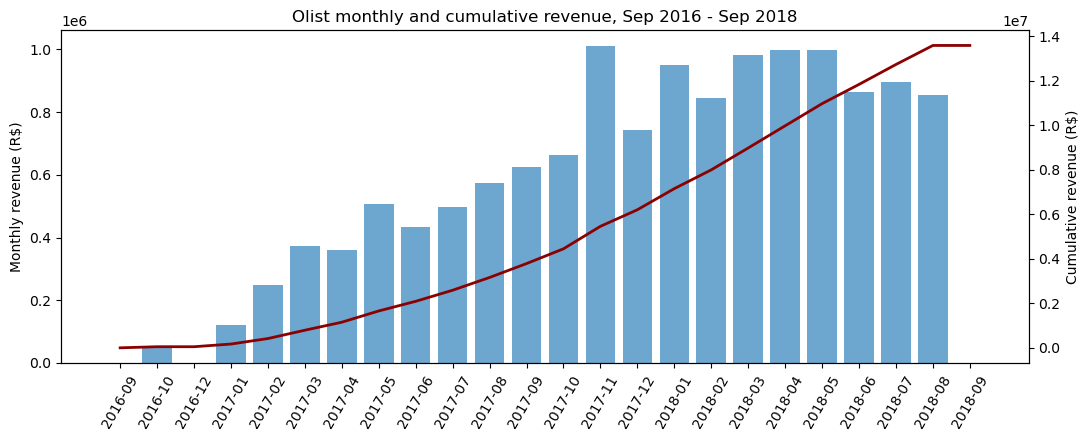

In [22]:
import matplotlib.pyplot as plt

monthly = pd.read_sql(q8, conn)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly["order_month"], monthly["monthly_total"], alpha=0.65, label="Monthly revenue")
ax1.set_ylabel("Monthly revenue (R$)")
ax1.tick_params(axis="x", rotation=60)

ax2 = ax1.twinx()
ax2.plot(monthly["order_month"], monthly["cumulative_revenue"],
         color="darkred", linewidth=2, label="Cumulative revenue")
ax2.set_ylabel("Cumulative revenue (R$)")

plt.title("Olist monthly and cumulative revenue, Sep 2016 - Sep 2018")
fig.tight_layout()
plt.show()

## Query 9 — Delivery speed vs. review score
*Technique: `CASE WHEN` bucketing + aggregation*

Ties the delivery-time analysis (Query 4) directly to customer satisfaction, this is the kind of query that turns into a one-sentence business recommendation.


In [23]:
q9 = """
SELECT
    CASE
        WHEN julianday(o.order_delivered_customer_date)
             <= julianday(o.order_estimated_delivery_date) THEN 'On time or early'
        WHEN julianday(o.order_delivered_customer_date)
             - julianday(o.order_estimated_delivery_date) <= 7 THEN 'Late (up to 7 days)'
        ELSE 'Very late (7+ days)'
    END AS delivery_bucket,
    COUNT(*) AS order_count,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY delivery_bucket
ORDER BY avg_review_score DESC;
"""
pd.read_sql(q9, conn)


,delivery_bucket,order_count,avg_review_score
0,On time or early,88658,4.29
1,Late (up to 7 days),4428,3.18
2,Very late (7+ days),3273,1.73


**Business insight:** This is the strongest relationship in the notebook. Bucketing by
delivery timing against the *estimated* date produces a near-linear drop in review score:

- **On time or early** — 88,658 orders (92.0%), avg review **4.29**
- **Late up to 7 days** — 4,428 orders (4.6%), avg review **3.18**
- **Very late, 7+ days** — 3,273 orders (3.4%), avg review **1.73**

Orders arriving more than a week late score **60% lower** than on-time ones. Combined with
Query 4's finding that delays cluster in the North and Northeast, this points to a specific,
addressable operational fix rather than a diffuse "improve customer service" conclusion.

## Key Takeaways

**1. Revenue is concentrated in a few categories, but volume and value diverge.**
`health_beauty` leads on total revenue (R$1.26M / 8,836 orders), while `watches_gifts`
earns nearly as much (R$1.21M) from 36% fewer orders — R$214 per order versus R$142.
`bed_bath_table` has the highest order count of the top three (9,417) at the lowest
per-order value (R$110). These require different commercial strategies.

**2. Geographic concentration is extreme.**
São Paulo alone accounts for R$5.20M, **38% of all platform revenue**, and the top three
states (SP, RJ, MG) together represent **63%**. This is both the platform's strength and its
single largest concentration risk.

**3. Delivery performance is the clearest driver of satisfaction in the dataset.**

| Delivery outcome | Orders | Share | Avg. review |
|---|---|---|---|
| On time or early | 88,658 | 92.0% | 4.29 |
| Late (up to 7 days) | 4,428 | 4.6% | 3.18 |
| Very late (7+ days) | 3,273 | 3.4% | 1.73 |

Orders arriving more than a week late score **60% lower** than on-time deliveries. With 8%
of delivered orders arriving late, this is the highest leverage operational fix available.

**4. Delivery delays follow a clear geographic pattern.**
The slowest states are all North/Northeast — Roraima (29.4 days), Amapá (27.2), Amazonas
(26.4), versus ~20 days elsewhere. These are the regions furthest from the São Paulo seller
base, so this compounds directly with finding #3.

**5. Category quality problems are visible and specific.**
`office_furniture` scores lowest among categories above 100 orders (3.49). More significant
are two high-volume categories near the bottom: `bed_bath_table` (9,313 orders, 3.90) and
`computers_accessories` (6,649 orders, 3.93).

**6. The marketplace has a long tail of very small sellers.**
The top São Paulo seller generated R$229K; several states' leading sellers clear only a few
hundred reais (Acre's top seller: R$267). Seller support cannot be one size fits all across
that range.

**7. Growth was strong but had flattened by 2018.**
Cumulative revenue reached R$13.59M. Monthly revenue climbed through 2017, spiked to R$1.01M
in November 2017 (+52% MoM), then plateaued around R$850K–1.0M through mid 2018.

**8. Data quality note.**
97.0% of 99,441 orders reached `delivered`; cancelled and unavailable together are 1.24%.
Revenue figures include all statuses, filtering to delivered only would shift absolute
values slightly but not relative rankings. The first and last months are partial.

### Recommended actions
1. **Prioritize delivery reliability in the North/Northeast** , small order volume, but it
   produces the most damaging review scores on the platform.
2. **Audit fulfilment for `bed_bath_table` and `computers_accessories`** , high volume plus
   sub-4.0 satisfaction reaches the most customers.
3. **Reassess concentration risk in São Paulo** , 38% of revenue from one state warrants a
   deliberate diversification position.
4. **Differentiate seller support by tier** , the revenue gap between top and long-tail
   sellers spans several orders of magnitude.

## Responsible Use
This is a historical (2016–2018), anonymized public dataset used for learning purposes.
No real customer identifying information is present or should be added.